In [1]:
import os

import galsim
import batsim
import anacal
import numpy as np
import matplotlib.pyplot as plt

from multiprocessing import cpu_count
from parallelbar import progress_starmap
from tqdm import tqdm
from time import time

from importlib import reload
reload(batsim)

<module 'batsim' from '/home/b7009348/FPFS-project/BATSim/src/batsim/__init__.py'>

Nyquist scale: 0.2000 arcsec/pixel
Good image size at Nyquist scale: 122 pixels


Text(0.5, 1.0, 'Residual (Galsim - BATSim)')

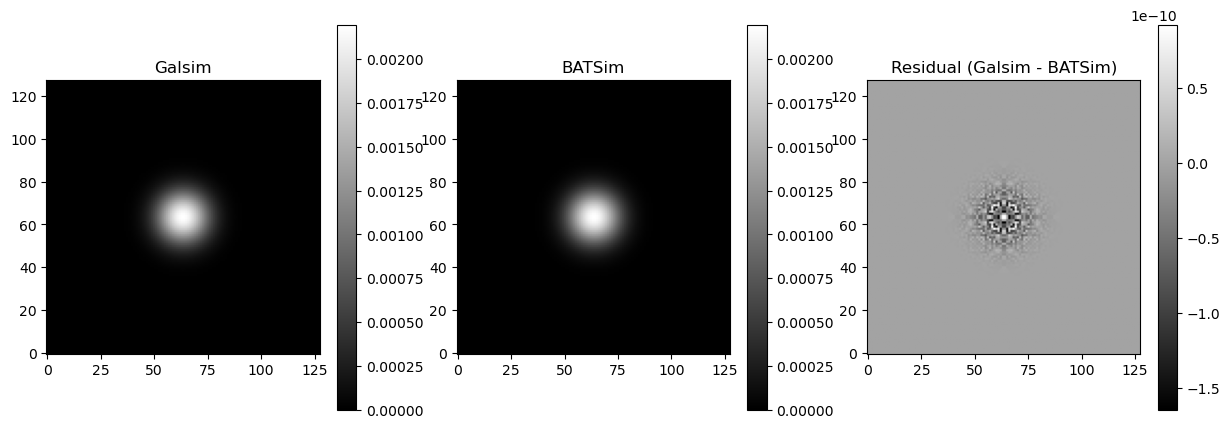

In [4]:
gal = galsim.Sersic(n=0.5, half_light_radius=2, flux=1)
psf = galsim.Moffat(beta=3.5, fwhm=0.7)

nyq = 0.2
npix = gal.getGoodImageSize(nyq)
print(f"Nyquist scale: {nyq:.4f} arcsec/pixel")
print(f"Good image size at Nyquist scale: {npix} pixels")

conv_gal = galsim.Convolve([gal, psf])

galsim_im = gal.drawImage(nx=128, ny=128, scale=nyq, method="no_pixel")

# Use BATSim to draw the same galaxy
bat_im = batsim.simulate_galaxy(
    ngrid=128,
    gal_obj=gal,
    psf_obj=None,
    pix_scale=nyq,
    draw_method="no_pixel"
)

residual = galsim_im.array - bat_im
plt.subplots(1, 3, figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(galsim_im.array, origin='lower', cmap='gray')
plt.colorbar()
plt.title("Galsim")
plt.subplot(1, 3, 2)
plt.imshow(bat_im, origin='lower', cmap='gray')
plt.colorbar()
plt.title("BATSim")
plt.subplot(1, 3, 3)
plt.imshow(residual, origin='lower', cmap='gray')
plt.colorbar()
plt.title("Residual (Galsim - BATSim)")

In [51]:
def wrap_kimage_full(kimg, out_size):
    """
    Periodically fold a full complex Fourier image down to out_size x out_size.
    """
    n = kimg.shape[0]
    out = np.zeros((out_size, out_size), dtype=kimg.dtype)
    for y in range(n):
        yy = y % out_size
        for x in range(n):
            xx = x % out_size
            out[yy, xx] += kimg[y, x]
    return out

0.012691144858388717
1020
Conv time: 0.2080 seconds


Text(0.5, 1.0, 'Residual (Galsim - BATSim)')

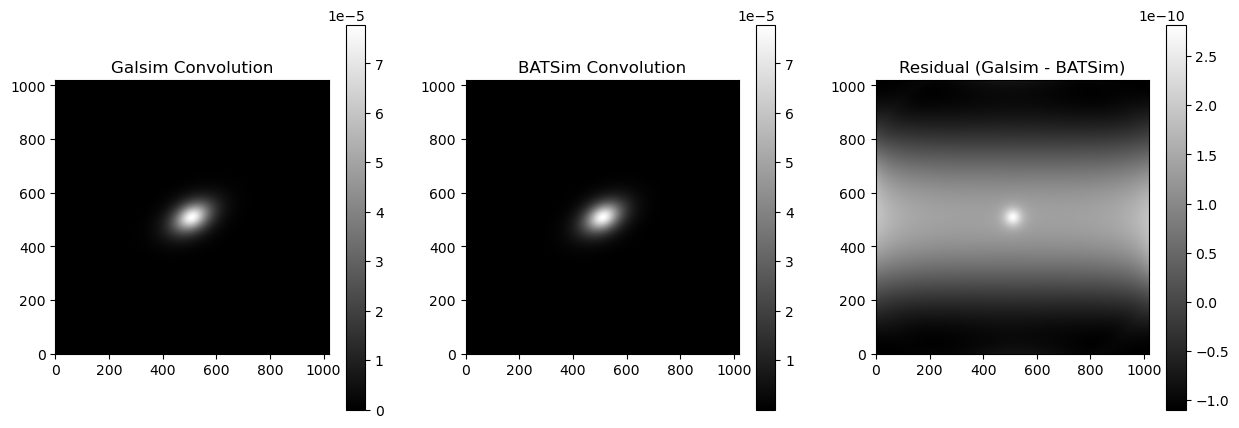

In [7]:
# Construct psf and galaxy profiles
psf = galsim.Moffat(beta=3.5, fwhm=0.7)
gal = galsim.Sersic(n=1, half_light_radius=0.5, flux=1).shear(g1=0.2, g2=0.3)
conv_gal = galsim.Convolve([gal, psf])

# Determine the appropriate scale and image size for convolution
# For testing we will draw at the appropriate rendering scale.
scale = min(psf.nyquist_scale, gal.nyquist_scale, conv_gal.nyquist_scale) / 5
print(scale)

# shift convolved galaxy 
conv_gal = conv_gal.shift(-0.5*scale, -0.5*scale)

# Determine image size and add padding
size = int(gal.getGoodImageSize(scale) * 2)
pad = 16
fft_size = size + 2*pad
print(size)

# Draw galaxy and PSF for convolution
gal_im = gal.drawImage(nx=fft_size, ny=fft_size, scale=scale, method="no_pixel").array
psf_im = psf.drawImage(nx=fft_size, ny=fft_size, scale=scale, method="no_pixel").array

start = time()
# FFT
gal_fft = galsim.fft.fft2(gal_im, shift_in=True, shift_out=False)
psf_fft = galsim.fft.fft2(psf_im, shift_in=False, shift_out=False)

# Convolve and IFFT
bat_conv_fft = gal_fft * psf_fft
bat_conv_im = galsim.fft.ifft2(bat_conv_fft, shift_in=False, shift_out=False).real

# Crop to size
bat_conv_im = bat_conv_im[pad:pad+size, pad:pad+size]

end = time()
print(f"Conv time: {end - start:.4f} seconds")

# Draw image from galsim.Convolve and compute residual
gal_conv_im = conv_gal.drawImage(nx=size, ny=size, scale=scale, method="no_pixel").array
residual = gal_conv_im - bat_conv_im

# Plot
plt.subplots(1, 3, figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(gal_conv_im, origin='lower', cmap='gray')
plt.colorbar()
plt.title("Galsim Convolution")
plt.subplot(1, 3, 2)
plt.imshow(bat_conv_im, origin='lower', cmap='gray')
plt.colorbar()
plt.title("BATSim Convolution")
plt.subplot(1, 3, 3)
plt.imshow(residual, origin='lower', cmap='gray')
plt.colorbar()
plt.title("Residual (Galsim - BATSim)")

In [53]:
# Load cosmos catalog
cosmos = galsim.COSMOSCatalog()

# Image pixel scale in arcsec/pixel
scale = 0.2

n_gal = 32
rng = galsim.BaseDeviate(14)
galaxies = cosmos.makeGalaxy(n_random=n_gal, gal_type='parametric', rng=rng)

# Define the PSF
psf = galsim.Moffat(beta=3.5, fwhm=0.7)

# convolve galaxies with PSF
convolved_galaxies = [galsim.Convolve([gal, psf]) for gal in galaxies]
convolved_galaxies = [gal.shift(-0.5 * scale, -0.5 * scale) for gal in convolved_galaxies]

In [54]:
max_diff = 0
for i in range(len(convolved_galaxies)):
    gal_size = galaxies[i].getGoodImageSize(scale)
    conv_size = convolved_galaxies[i].getGoodImageSize(scale)
    diff = abs(conv_size - gal_size)

    if diff > max_diff:
        max_diff = diff

print(f"Maximum size difference between original and convolved galaxies: {max_diff} pixels")

Maximum size difference between original and convolved galaxies: 18 pixels


In [55]:
# Define spacing of galaxies in the grid (in pixels)
grid_spacing = 64
grid_n = np.ceil(np.sqrt(n_gal))

# Create an empty image to hold the scene
galsim_scene = galsim.ImageF(grid_n * grid_spacing, grid_n * grid_spacing, scale=scale)
galsim_scene.setZero()

# Draw each convolved galaxy onto the scene at the appropriate position
for i, obj in tqdm(enumerate(convolved_galaxies)):

    row = i // grid_n # Integer division to get the row index
    col = i % grid_n # Modulo to get the column index

    x = col * grid_spacing + grid_spacing / 2 # Center of the cell in x
    y = row * grid_spacing + grid_spacing / 2 # Center of the cell in y

    obj.drawImage(
        image=galsim_scene,
        center=galsim.PositionD(x, y),
        add_to_image=True,
        method="auto"
    )

print(galsim_scene.array.shape)

32it [00:00, 151.98it/s]

32it [00:00, 151.45it/s]

(384, 384)


Text(0.5, 1.0, 'Galsim')

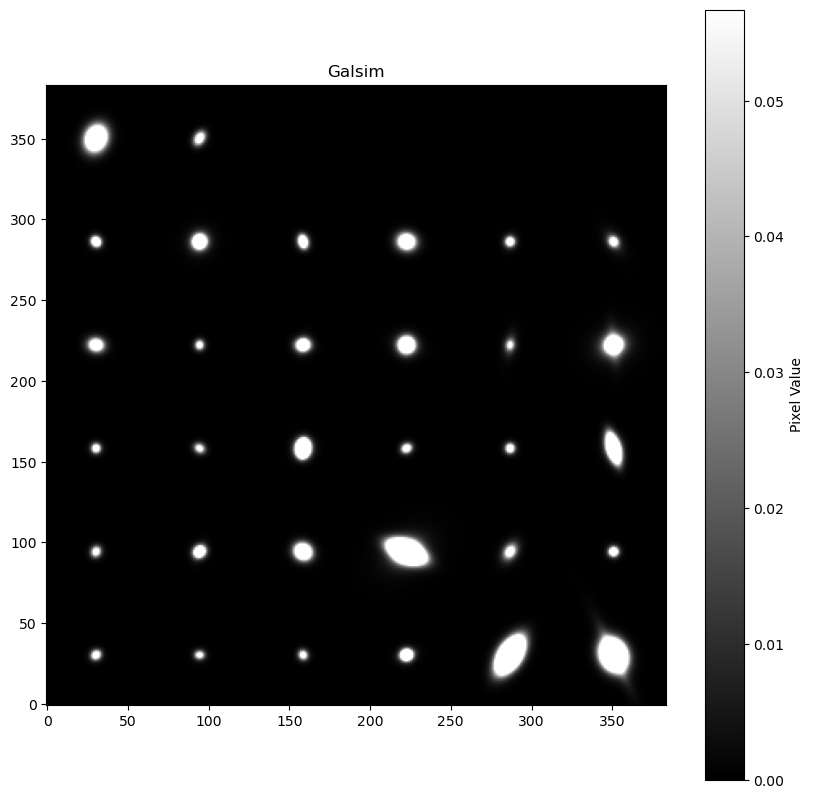

In [56]:
plt.figure(figsize=(10, 10))
plt.imshow(galsim_scene.array, origin='lower', cmap='gray', vmin=0, vmax=np.percentile(galsim_scene.array, 98.5))
plt.colorbar(label='Pixel Value')
plt.title("Galsim")

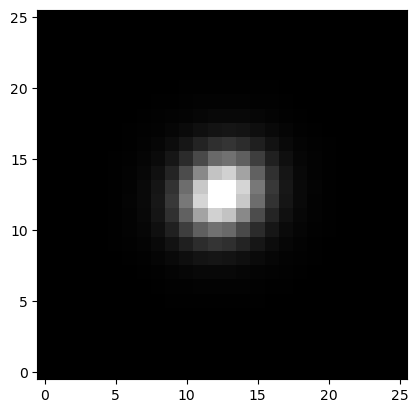

In [57]:
# Repeat process with BATSim
gal_im = batsim.simulate_galaxy(
    gal_obj=galaxies[0],
    ngrid=convolved_galaxies[0].getGoodImageSize(scale),
    psf_obj=psf,
    pix_scale=scale,
    draw_method="auto",
    maximum_num_grids=4096
)
plt.imshow(gal_im, origin='lower', cmap='gray', vmin=0, vmax=np.percentile(gal_im, 99.5))

In [58]:
# Define spacing of galaxies in the grid (in pixels)
grid_spacing = 64
grid_n = np.ceil(np.sqrt(n_gal))

# Create an empty image to hold the scene
bat_scene = galsim.ImageF(grid_n * grid_spacing, grid_n * grid_spacing, scale=scale)
bat_scene.setZero()

# Draw each convolved galaxy onto the scene at the appropriate position
for i, obj in tqdm(enumerate(galaxies)):
    row = i // grid_n # Integer division to get the row index
    col = i % grid_n # Modulo to get the column index

    x = col * grid_spacing + grid_spacing / 2 # Center of the cell in x
    y = row * grid_spacing + grid_spacing / 2 # Center of the cell in y

    # Use BATSim to draw the galaxy onto the scene
    gal_im = batsim.simulate_galaxy(
        gal_obj=obj,
        psf_obj=psf,
        pix_scale=scale,
        draw_method="auto"
    )

    # Wrap NumPy array as a GalSim image
    stamp = galsim.ImageF(gal_im, scale=scale)

    # Place the stamp centre at the desired scene location
    stamp.setCenter(np.floor(x), np.floor(y))

    # Add only the overlapping region
    overlap = stamp.bounds & bat_scene.bounds
    if overlap.isDefined():
        bat_scene[overlap] += stamp[overlap]

print(bat_scene.array.shape)

32it [00:01, 17.53it/s]

(384, 384)


Text(0.5, 1.0, 'BATSim')

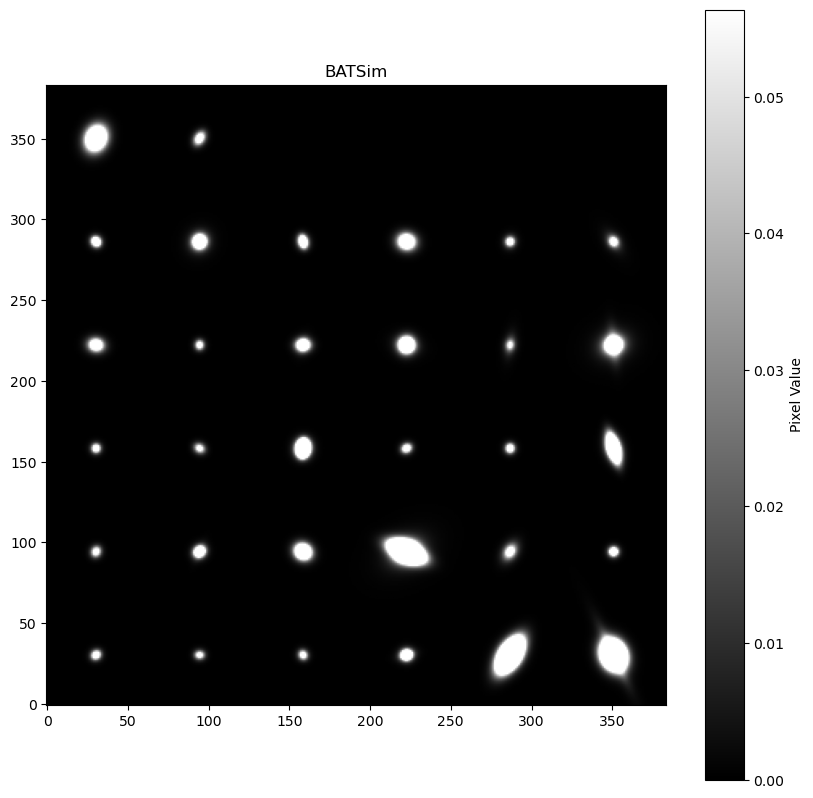

In [59]:
plt.figure(figsize=(10, 10))
plt.imshow(bat_scene.array, origin='lower', cmap='gray', vmin=0, vmax=np.percentile(bat_scene.array, 98.5))
plt.colorbar(label='Pixel Value')
plt.title("BATSim")

Text(0.5, 1.0, 'Residual between Galsim and BATSim')

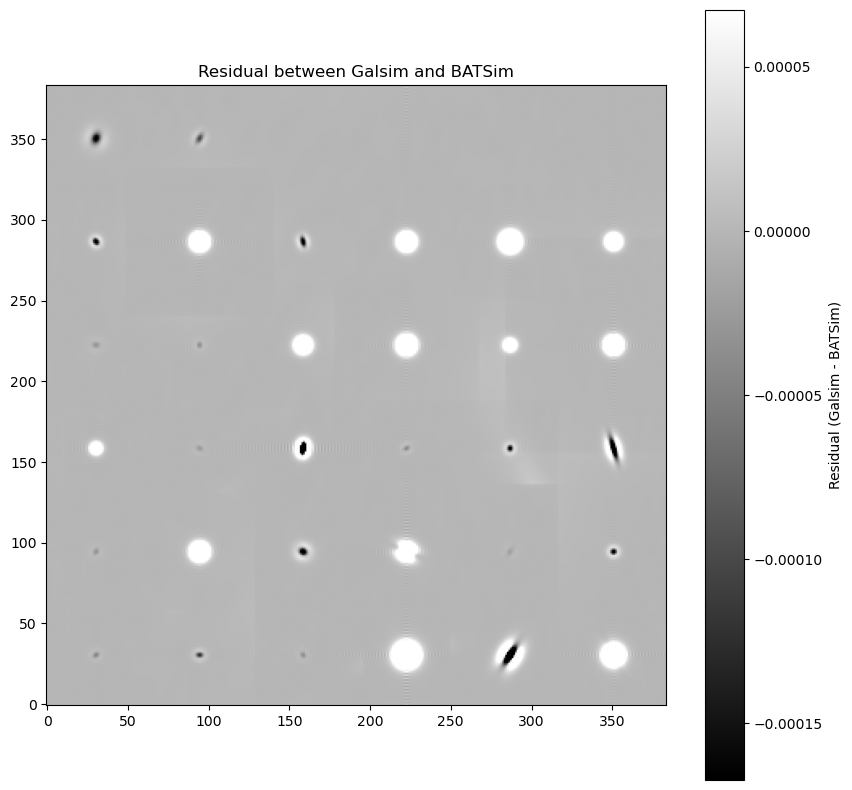

In [60]:
# Show residual between the two scenes
residual = galsim_scene - bat_scene
plt.figure(figsize=(10, 10))
plt.imshow(residual.array, origin='lower', cmap='gray', vmin=-np.percentile(residual.array, 99), vmax=np.percentile(residual.array, 98.5))
plt.colorbar(label='Residual (Galsim - BATSim)')
plt.title("Residual between Galsim and BATSim")